# 05. Stability

Turney's definition, the one the course uses: two datasets drawn from the same population should
produce approximately **the same model**. So stability is a distance between models, not the spread
of a score. A model whose accuracy is steady while its coefficients jump around is unstable, and the
client would notice, because the explanation given to a user would change every time the engine is retrained.

We measure it three ways: across resamples, across time, and on the one thing the user actually sees,
the ranking.

**The three conventions from 04 apply here too**: Ŷ = 1 means the pair is in the top K, every number
carries a bootstrap interval resampled within waves, and the two stages are combined in logs.

In [1]:
%matplotlib inline

import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.stats import kendalltau
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

if not Path("data").is_dir():
    os.chdir("..")

Path("reports/figures").mkdir(parents=True, exist_ok=True)
Path("reports/tables").mkdir(parents=True, exist_ok=True)

SEED = 42
table = pd.read_csv("data/processed/model_table.csv")
oof = pd.read_csv("data/processed/oof_predictions.csv")

TARGETS = ["pair", "wave", "match", "fold", "her_dec", "his_dec"]
SIDE_CATEGORICAL = ["self_field", "self_race", "self_goal", "other_field", "other_race", "other_goal"]

def decision_view(tab, decider):
    mine, theirs = ("her", "his") if decider == "her" else ("his", "her")
    view = tab.drop(columns=TARGETS).rename(
        columns=lambda c: c.replace(f"{mine}_", "self_").replace(f"{theirs}_", "other_"))
    view["agediff"] = view.self_age - view.other_age
    view["female"] = int(decider == "her")
    return view

def two_stage(final_step, scale):
    encode = ColumnTransformer(
        [("categories", OneHotEncoder(min_frequency=0.03, handle_unknown="infrequent_if_exist",
                                      sparse_output=False), SIDE_CATEGORICAL)], remainder="passthrough")
    steps = [encode, SimpleImputer(strategy="median")]
    if scale:
        steps.append(StandardScaler())
    return make_pipeline(*steps, final_step)

BUILD = {
    "logit": lambda: two_stage(LogisticRegression(max_iter=3000, C=0.05, l1_ratio=1,
                                                  solver="liblinear"), scale=True),
    "xgboost": lambda: two_stage(XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                                               subsample=0.8, colsample_bytree=0.8,
                                               eval_metric="logloss", random_state=0), scale=False)}

hers, his = decision_view(table, "her"), decision_view(table, "his")
print(len(table), "pairs,", table.wave.nunique(), "waves")

4184 pairs, 21 waves


In [2]:
def fit_on(name, pairs):
    # Train on a set of pair indices: each pair contributes her decision and his decision.
    rows = pd.concat([hers.loc[pairs], his.loc[pairs]], ignore_index=True)
    answers = pd.concat([table.her_dec[pairs], table.his_dec[pairs]], ignore_index=True)
    return BUILD[name]().fit(rows, answers)

def signature(name, model):
    # What we compare between two fits: standardised coefficients, or normalised importances.
    # The encoder keeps a category only if it is frequent enough, so a resample can produce a
    # slightly different set of columns. We line every fit up on the columns of the full model,
    # where a column a resample never saw counts as zero.
    columns = [c.split("__", 1)[-1] for c in model[0].get_feature_names_out()]
    if name == "logit":
        return pd.Series(model[-1].coef_.ravel(), index=columns).reindex(COLUMNS).fillna(0.0)
    weights = pd.Series(model[-1].feature_importances_, index=columns)
    return (weights / weights.sum()).reindex(COLUMNS).fillna(0.0)

def pair_score(model, pairs):
    return model.predict_proba(hers.loc[pairs])[:, 1] * model.predict_proba(his.loc[pairs])[:, 1]

reference = fit_on("logit", table.index)
COLUMNS = [c.split("__", 1)[-1] for c in reference[0].get_feature_names_out()]
print(len(COLUMNS), "columns after encoding")

101 columns after encoding


## 1. Across resamples

Twenty-five versions of each model: the five cross-validation folds, and twenty bootstrap resamples
drawn **within waves** so every resample keeps the structure of the experiment. Then the distance
between every pair of versions.

In [3]:
rng = np.random.default_rng(SEED)
blocks = [g.index.to_numpy() for _, g in table.groupby("wave")]

samples = {f"fold {k}": table.index[table.fold != k] for k in sorted(table.fold.unique())}
for b in range(20):
    samples[f"boot {b}"] = pd.Index(np.concatenate([rng.choice(x, len(x), True) for x in blocks]))

fits = {name: {label: fit_on(name, pairs) for label, pairs in samples.items()} for name in BUILD}
signatures = {name: pd.DataFrame({label: signature(name, model) for label, model in group.items()})
              for name, group in fits.items()}

widths = pd.Series({label: len(model[0].get_feature_names_out()) for label, model in fits["logit"].items()})
print(len(samples), "versions of each model")
print(f"columns after encoding: {widths.min()} to {widths.max()} depending on the resample")

25 versions of each model
columns after encoding: 99 to 105 depending on the resample


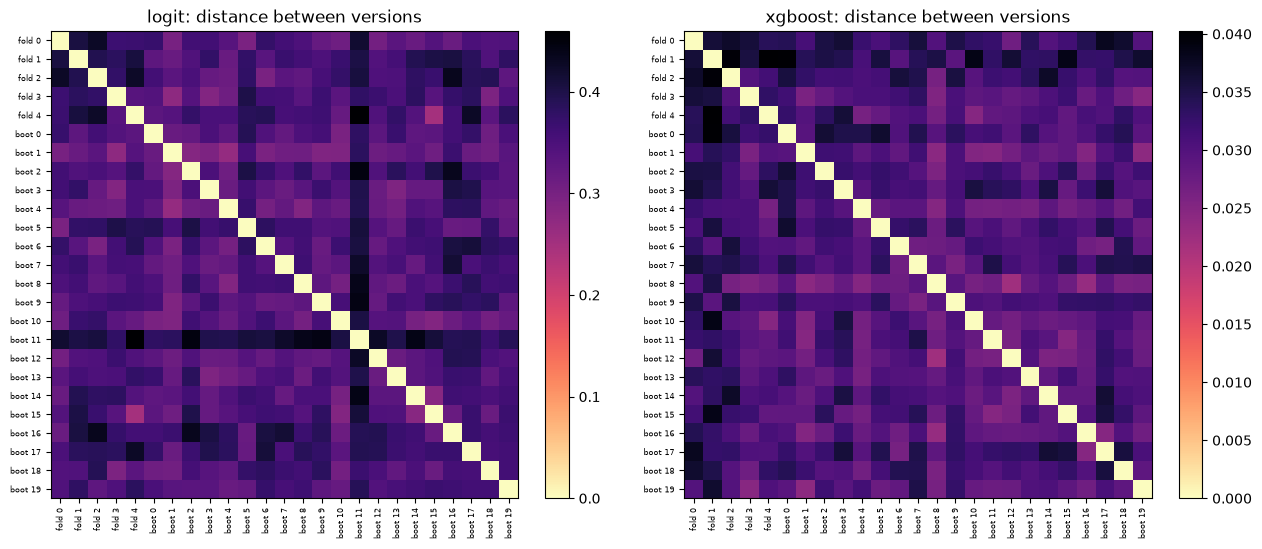

In [4]:
def distance_matrix(frame):
    values = frame.to_numpy().T
    return pd.DataFrame(np.linalg.norm(values[:, None, :] - values[None, :, :], axis=2),
                        index=frame.columns, columns=frame.columns)

distances = {name: distance_matrix(frame) for name, frame in signatures.items()}

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, (name, matrix) in zip(axes, distances.items()):
    image = ax.imshow(matrix, cmap="magma_r")
    ax.set_title(f"{name}: distance between versions")
    ax.set_xticks(range(len(matrix)), matrix.columns, rotation=90, fontsize=6)
    ax.set_yticks(range(len(matrix)), matrix.columns, fontsize=6)
    fig.colorbar(image, ax=ax, fraction=0.046)
plt.tight_layout()
plt.savefig("reports/figures/05_distance_heatmaps.png", dpi=150)
plt.show()

In [5]:
summary = []
for name, matrix in distances.items():
    off = matrix.to_numpy()[np.triu_indices(len(matrix), 1)]
    size = np.linalg.norm(signatures[name].mean(axis=1))
    summary.append({"model": name, "mean distance": round(off.mean(), 3),
                    "worst pair": round(off.max(), 3),
                    "size of the average model": round(size, 3),
                    "instability (mean distance / size)": round(off.mean() / size, 2)})

instability = pd.DataFrame(summary).set_index("model")
instability.to_csv("reports/tables/05_instability.csv")
instability

,mean distance,worst pair,size of the average model,instability (mean distance / size)
model,,,,
logit,0.352,0.46,0.628,0.56
xgboost,0.031,0.04,0.103,0.30


The two numbers are on different scales, since a coefficient vector and a vector of importance
shares are not the same object, so only the last column compares them: the typical distance between two
versions, relative to the size of the average model.

In [6]:
coefficients = signatures["logit"]
signs = np.sign(coefficients)
drift = pd.DataFrame({
    "mean": coefficients.mean(axis=1), "std": coefficients.std(axis=1),
    "dropped by the lasso (%)": 100 * (coefficients == 0).mean(axis=1),
    "sign changes (%)": 100 * (signs.ne(np.sign(coefficients.mean(axis=1)), axis=0)
                               & signs.ne(0)).mean(axis=1)})
drift = drift.reindex(drift["mean"].abs().sort_values(ascending=False).index)
drift.to_csv("reports/tables/05_coefficient_drift.csv")
drift.head(15).round(3)

,mean,std,dropped by the lasso (%),sign changes (%)
female,-0.288,0.041,0.0,0.0
self_optimism,0.158,0.023,0.0,0.0
other_selfintel,-0.140,0.034,0.0,0.0
raceclash,-0.138,0.028,0.0,0.0
self_race_2.0,-0.135,0.027,0.0,0.0
other_race_4.0,-0.120,0.041,0.0,0.0
other_wantshar,-0.117,0.027,0.0,0.0
other_datefreq,-0.097,0.031,0.0,0.0
self_racepref,-0.097,0.031,0.0,0.0
other_field_11.0,-0.096,0.032,0.0,0.0


In [7]:
strong = drift[drift["mean"].abs() > 0.02]
print(f"{len(strong)} columns with a non-negligible average coefficient")
print(f"of those, {(strong['sign changes (%)'] > 0).sum()} change sign in at least one of the 25 versions")
print(f"and {(strong['dropped by the lasso (%)'] > 20).sum()} are dropped by the lasso in more than a fifth of them")

55 columns with a non-negligible average coefficient
of those, 2 change sign in at least one of the 25 versions
and 6 are dropped by the lasso in more than a fifth of them


## 2. Stability of the ranking

The distances above are about the model. The user sees a **list**. Two versions can differ in their
coefficients and still show the same profiles, or agree on the coefficients and reshuffle the list,
so this is worth measuring on its own.

Every version scores all 4,184 pairs, and we compare the lists: Jaccard on the top decile, Kendall's
tau on the full ranking.

In [8]:
def ranking_agreement(name, labels, k=0.10):
    scores = {label: pair_score(fits[name][label], table.index) for label in labels}
    tops = {label: set(np.argsort(-s)[:int(k * len(s))]) for label, s in scores.items()}
    jaccard, tau = [], []
    for i, a in enumerate(labels):
        for b in labels[i + 1:]:
            jaccard.append(len(tops[a] & tops[b]) / len(tops[a] | tops[b]))
            tau.append(kendalltau(scores[a], scores[b]).statistic)
    return np.mean(jaccard), np.mean(tau)

rows = []
for name in BUILD:
    for group in ["fold", "boot"]:
        labels = [l for l in samples if l.startswith(group)]
        jaccard, tau = ranking_agreement(name, labels)
        rows.append({"model": name, "versions": group, "Jaccard on the top decile": round(jaccard, 3),
                     "Kendall tau on the full ranking": round(tau, 3)})

stability_of_ranking = pd.DataFrame(rows).set_index(["model", "versions"])
stability_of_ranking.to_csv("reports/tables/05_ranking_stability.csv")
stability_of_ranking

Jaccard on the top decile  Kendall tau on the full ranking
model   versions                                                            
logit   fold                          0.484                            0.658
        boot                          0.464                            0.645
xgboost fold                          0.435                            0.562
        boot                          0.385                            0.556

In [9]:
# Between families, on the out-of-fold scores: do the white box and the black box show the same people?
top = {name: set(oof.nlargest(int(0.1 * len(oof)), name).index) for name in ["logit", "xgboost"]}
print(f"Jaccard between logit and xgboost, top decile: "
      f"{len(top['logit'] & top['xgboost']) / len(top['logit'] | top['xgboost']):.3f}")
print(f"Kendall tau between the two rankings: {kendalltau(oof.logit, oof.xgboost).statistic:.3f}")

Jaccard between logit and xgboost, top decile: 0.342
Kendall tau between the two rankings: 0.462


## 3. Across time: leave one wave out

The 21 waves ran over two years, with different instructions and different group sizes. Training on
twenty of them and holding out the twenty-first is the closest thing this dataset has to a model
retrained next month and used on new users.

In [10]:
rows = []
for wave in sorted(table.wave.unique()):
    train = table.index[table.wave != wave]
    test = table.index[table.wave == wave]
    model = fit_on("logit", train)
    score = pair_score(model, test)
    held_out = table.loc[test]
    rows.append({"wave": wave, "pairs": len(test), "match rate": held_out.match.mean(),
                 "PR-AUC": average_precision_score(held_out.match, score) if held_out.match.nunique() > 1 else np.nan,
                 "distance to the full model": np.linalg.norm(signature("logit", model) - signature("logit", reference))})

by_wave = pd.DataFrame(rows).set_index("wave")
by_wave.to_csv("reports/tables/05_leave_one_wave_out.csv")
by_wave.round(3)

,pairs,match rate,PR-AUC,distance to the full model
wave,,,,
1,100,0.310,0.459,0.079
2,304,0.102,0.258,0.158
3,100,0.130,0.286,0.074
4,324,0.201,0.327,0.149
5,90,0.300,0.430,0.078
6,25,0.200,0.291,0.023
7,256,0.168,0.308,0.086
8,100,0.180,0.322,0.069
9,400,0.155,0.261,0.158


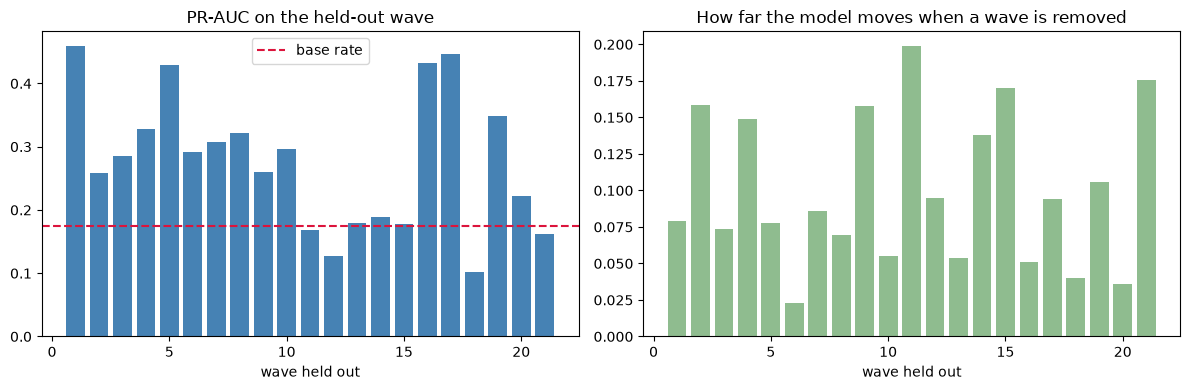

correlation between wave size and how far the model moves: 0.96
worst wave: 18, PR-AUC 0.103 on 36 pairs with a 8% match rate
spread across waves: 0.103 to 0.459


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(by_wave.index, by_wave["PR-AUC"], color="steelblue")
axes[0].axhline(by_wave["match rate"].mean(), color="crimson", linestyle="--", label="base rate")
axes[0].set_title("PR-AUC on the held-out wave")
axes[0].set_xlabel("wave held out")
axes[0].legend()

axes[1].bar(by_wave.index, by_wave["distance to the full model"], color="darkseagreen")
axes[1].set_title("How far the model moves when a wave is removed")
axes[1].set_xlabel("wave held out")
plt.tight_layout()
plt.savefig("reports/figures/05_leave_one_wave_out.png", dpi=150)
plt.show()

print(f"correlation between wave size and how far the model moves: "
      f"{by_wave.pairs.corr(by_wave['distance to the full model']):.2f}")
worst = by_wave["PR-AUC"].idxmin()
print(f"worst wave: {worst}, PR-AUC {by_wave['PR-AUC'].min():.3f} on {by_wave.pairs[worst]} pairs "
      f"with a {by_wave['match rate'][worst]:.0%} match rate")
print(f"spread across waves: {by_wave['PR-AUC'].min():.3f} to {by_wave['PR-AUC'].max():.3f}")

The right column is almost entirely a sample-size effect: it correlates 0.96 with the number of
pairs removed. Dropping wave 21 moves the model more than dropping wave 6 because it is 484 pairs
against 25, not because that evening was unusual. What does vary for real is the performance: from
0.10 to 0.46 PR-AUC depending on the evening held out. A model retrained next month would land
somewhere in that range, and the client should be told the range, not the average.

## 4. Buying stability (secondary)

The course's last point: stability can be imposed. We refit the fold-1 model with a penalty pulling
its coefficients towards those of the fold-0 model, λ‖θ − θ̂₀‖², and watch what it costs.

In [12]:
def anchored_logit(matrix, y, anchor, lam):
    # Logistic loss plus a pull towards `anchor`; gradient supplied so it converges quickly.
    X, y = matrix.to_numpy(), y.to_numpy().astype(float)
    def objective(t):
        z = t[0] + X @ t[1:]
        loss = (np.logaddexp(0, z) - y * z).mean() + lam * ((t[1:] - anchor) ** 2).sum()
        residual = 1 / (1 + np.exp(-z)) - y
        return loss, np.r_[residual.mean(), X.T @ residual / len(y) + 2 * lam * (t[1:] - anchor)]
    start = np.r_[0.0, anchor]
    return minimize(objective, start, jac=True, method="L-BFGS-B").x

train = table.index[table.fold != 1]
test = table.index[table.fold == 1]
pipe = fits["logit"]["fold 1"]
own = [c.split("__", 1)[-1] for c in pipe[0].get_feature_names_out()]   # this fit's own columns

def side_matrix(pairs):
    rows = pd.concat([hers.loc[pairs], his.loc[pairs]], ignore_index=True)
    return pd.DataFrame(pipe[:-1].transform(rows), columns=own)

anchor = signature("logit", fits["logit"]["fold 0"]).reindex(own).fillna(0.0).to_numpy()
matrix = side_matrix(train)
y_train = pd.concat([table.her_dec[train], table.his_dec[train]], ignore_index=True)

def scored(theta):
    her = pipe[:-1].transform(hers.loc[test])
    him = pipe[:-1].transform(his.loc[test])
    p = lambda m: 1 / (1 + np.exp(-(theta[0] + m @ theta[1:])))
    return p(her) * p(him)

rows = []
for lam in [0, 0.001, 0.003, 0.01, 0.03, 0.1, 0.3]:
    theta = anchored_logit(matrix, y_train, anchor, lam)
    rows.append({"lambda": lam,
                 "PR-AUC on fold 1": average_precision_score(table.match[test], scored(theta)),
                 "distance to fold 0": np.linalg.norm(theta[1:] - anchor)})

trade_off = pd.DataFrame(rows).set_index("lambda")
trade_off["performance change (%)"] = 100 * (trade_off["PR-AUC on fold 1"] / trade_off["PR-AUC on fold 1"].iloc[0] - 1)
trade_off["stability gained (%)"] = 100 * (1 - trade_off["distance to fold 0"] / trade_off["distance to fold 0"].iloc[0])
trade_off.to_csv("reports/tables/05_stability_trade_off.csv")
trade_off.round(3)

,PR-AUC on fold 1,distance to fold 0,performance change (%),stability gained (%)
lambda,,,,
0.000,0.287,0.581,0.000,0.000
0.001,0.286,0.494,-0.366,14.969
0.003,0.289,0.434,0.711,25.323
0.010,0.295,0.360,2.918,37.962
0.030,0.298,0.282,3.739,51.493
0.100,0.308,0.179,7.207,69.202
0.300,0.312,0.095,8.838,83.661


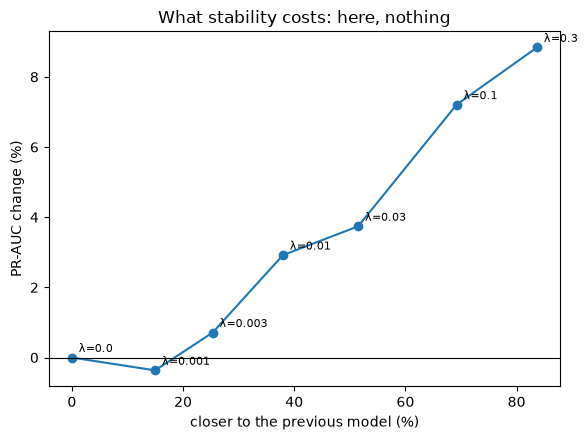

In [13]:
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(trade_off["stability gained (%)"], trade_off["performance change (%)"], "o-")
for lam, row in trade_off.iterrows():
    ax.annotate(f"λ={lam}", (row["stability gained (%)"], row["performance change (%)"]),
                textcoords="offset points", xytext=(5, 4), fontsize=8)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("closer to the previous model (%)")
ax.set_ylabel("PR-AUC change (%)")
ax.set_title("What stability costs: here, nothing")
plt.tight_layout()
plt.savefig("reports/figures/05_stability_trade_off.png", dpi=150)
plt.show()

It does not cost anything. Pulling the fold-1 model 84% of the way towards the fold-0 model raises
its out-of-fold PR-AUC from 0.287 to 0.312. The course's figure shows stability being bought with
performance; here the two move together, and the reason is in the first section: with 55 columns
carrying a real coefficient and 3,300 pairs per fold, the unconstrained fit is overfitting the fold.
Anchoring it to another fold is simply extra regularisation.

That is a result worth stating rather than hiding: on this data there is no trade-off to arbitrate.

## What goes on the slide

In [14]:
print(instability["instability (mean distance / size)"].to_string())
print(f"\ncolumns that change sign across the 25 versions: "
      f"{(strong['sign changes (%)'] > 0).sum()} of {len(strong)}")
print(f"top decile shared between two fold models: "
      f"{stability_of_ranking.loc[('logit', 'fold'), 'Jaccard on the top decile']:.2f} (Jaccard)")
print(f"top decile shared between the white box and the black box: "
      f"{len(top['logit'] & top['xgboost']) / len(top['logit'] | top['xgboost']):.2f}")
print(f"PR-AUC across the 21 held-out waves: {by_wave['PR-AUC'].min():.2f} to {by_wave['PR-AUC'].max():.2f}")

model
logit      0.56
xgboost    0.30

columns that change sign across the 25 versions: 2 of 55
top decile shared between two fold models: 0.48 (Jaccard)
top decile shared between the white box and the black box: 0.34
PR-AUC across the 21 held-out waves: 0.10 to 0.46
